# 1. 라이브러리 IMPORT

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import requests
import random
import json
import seaborn as sns
import matplotlib.pyplot as plt
import io

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
from collections import OrderedDict

C:\Users\choiyoungjun\anaconda3\lib\site-packages\requests\__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.14) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


# 2. 함수 및 모델 정의

In [2]:
class LTSF_Linear(torch.nn.Module):
    def __init__(self, window_size, forcast_size, individual, feature_size):
        super(LTSF_Linear, self).__init__()
        self.window_size = window_size
        self.forcast_size = forcast_size
        self.individual = individual
        self.channels = feature_size
        if self.individual:
            self.Linear = torch.nn.ModuleList()
            for i in range(self.channels):
                self.Linear.append(torch.nn.Linear(self.window_size, self.forcast_size))
        else:
            self.Linear = torch.nn.Linear(self.window_size, self.forcast_size)

    def forward(self, x):
        if self.individual:
            output = torch.zeros([x.size(0),self.pred_len,x.size(2)],dtype=x.dtype).to(x.device)
            for i in range(self.channels):
                output[:,:,i] = self.Linear[i](x[:,:,i])
            x = output
        else:
            x = self.Linear(x.permute(0,2,1)).permute(0,2,1)
        return x

In [3]:
class LTSF_NLinear(torch.nn.Module):
    def __init__(self, window_size, forcast_size, individual, feature_size):
        super(LTSF_NLinear, self).__init__()
        self.window_size = window_size
        self.forcast_size = forcast_size
        self.individual = individual
        self.channels = feature_size
        if self.individual:
            self.Linear = torch.nn.ModuleList()
            for i in range(self.channels):
                self.Linear.append(torch.nn.Linear(self.window_size, self.forcast_size))
        else:
            self.Linear = torch.nn.Linear(self.window_size, self.forcast_size)

    def forward(self, x):
        seq_last = x[:,-1:,:].detach()
        x = x - seq_last
        if self.individual:
            output = torch.zeros([x.size(0), self.forcast_size, x.size(2)],dtype=x.dtype).to(x.device)
            for i in range(self.channels):
                output[:,:,i] = self.Linear[i](x[:,:,i])
            x = output
        else:
            x = self.Linear(x.permute(0,2,1)).permute(0,2,1)
        x = x + seq_last
        return x

In [4]:
class moving_avg(torch.nn.Module):
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x

class series_decomp(torch.nn.Module):
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        residual = x - moving_mean
        return moving_mean, residual 
        
class LTSF_DLinear(torch.nn.Module):
    def __init__(self, window_size, forcast_size, kernel_size, individual, feature_size):
        super(LTSF_DLinear, self).__init__()
        self.window_size = window_size
        self.forcast_size = forcast_size
        self.decompsition = series_decomp(kernel_size)
        self.individual = individual
        self.channels = feature_size
        if self.individual:
            self.Linear_Seasonal = torch.nn.ModuleList()
            self.Linear_Trend = torch.nn.ModuleList()
            for i in range(self.channels):
                self.Linear_Trend.append(torch.nn.Linear(self.window_size, self.forcast_size))
                self.Linear_Trend[i].weight = torch.nn.Parameter((1/self.window_size)*torch.ones([self.forcast_size, self.window_size]))
                self.Linear_Seasonal.append(torch.nn.Linear(self.window_size, self.forcast_size))
                self.Linear_Seasonal[i].weight = torch.nn.Parameter((1/self.window_size)*torch.ones([self.forcast_size, self.window_size]))
        else:
            self.Linear_Trend = torch.nn.Linear(self.window_size, self.forcast_size)
            self.Linear_Trend.weight = torch.nn.Parameter((1/self.window_size)*torch.ones([self.forcast_size, self.window_size]))
            self.Linear_Seasonal = torch.nn.Linear(self.window_size,  self.forcast_size)
            self.Linear_Seasonal.weight = torch.nn.Parameter((1/self.window_size)*torch.ones([self.forcast_size, self.window_size]))

    def forward(self, x):
        trend_init, seasonal_init = self.decompsition(x)
        trend_init, seasonal_init = trend_init.permute(0,2,1), seasonal_init.permute(0,2,1)
        if self.individual:
            trend_output = torch.zeros([trend_init.size(0), trend_init.size(1), self.forcast_size], dtype=trend_init.dtype).to(trend_init.device)
            seasonal_output = torch.zeros([seasonal_init.size(0), seasonal_init.size(1), self.forcast_size], dtype=seasonal_init.dtype).to(seasonal_init.device)
            for idx in range(self.channels):
                trend_output[:, idx, :] = self.Linear_Trend[idx](trend_init[:, idx, :])
                seasonal_output[:, idx, :] = self.Linear_Seasonal[idx](seasonal_init[:, idx, :])                
        else:
            trend_output = self.Linear_Trend(trend_init)
            seasonal_output = self.Linear_Seasonal(seasonal_init)
        x = seasonal_output + trend_output
        return x.permute(0,2,1)

In [5]:
class Data(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [6]:
def day_cal(dataset):
    day_list = []

    for i in range(len(dataset)-1):
        if dataset.index[i][0] != dataset.index[i+1][0]:
            day_list.append(i)

    day_list.append(len(dataset))
    return day_list

In [7]:
def make_dataset(dataset, target, history_size,cusnum_len, day, target_size):
    
    data = []
    labels = []
    check_point = 0
    check_list = []
    k = 0

    for i in range(cusnum_len):        
        start_index = check_point + history_size 
        end_index = day[i]

        for j in range(start_index, end_index, 1):
            if j+target_size <= end_index:
                indices = range(j-history_size, j)         
                data.append(dataset[indices])
                labels.append(target[j:j+target_size])
                check_point = end_index
                k = k + 1
            else :
                break
            
            #print("last x_data : ",indices)
            #print('last y_data_start : ', j)
            #print('last y_data_end : ', j+target_size)
            
        check_list.append(k)
    return np.array(data), np.array(labels),check_list

# 3. 데이터셋 불러오기

In [8]:
health_dataset = pd.read_csv("final_health.csv")
health_dataset2 = health_dataset[['WEARABLE_ID','TIME','DIASTOLIC','SYSTOLIC']]
health_dataset2
id_len = health_dataset2['WEARABLE_ID'].nunique()

In [9]:
health_dataset2

,WEARABLE_ID,TIME,DIASTOLIC,SYSTOLIC
0,1,2023-04-27 00:00:00,90.0,145.0
1,1,2023-04-27 01:00:00,81.0,147.0
2,1,2023-04-27 02:00:00,83.0,138.0
3,1,2023-04-27 03:00:00,99.0,155.0
4,1,2023-04-27 04:00:00,100.0,152.0
...,...,...,...,...
201587,600,2023-05-10 19:00:00,102.0,169.0
201588,600,2023-05-10 20:00:00,97.0,151.0
201589,600,2023-05-10 21:00:00,110.0,146.0
201590,600,2023-05-10 22:00:00,84.0,138.0


In [10]:
health_dataset2.set_index(['WEARABLE_ID',"TIME"], drop=False, inplace=True)
health_dataset2.drop(['WEARABLE_ID'], axis=1, inplace=True)
health_dataset2.drop(['TIME'], axis=1, inplace=True)
health_dataset2 = health_dataset2.sort_index(ascending=True)
health_dataset2

C:\Users\choiyoungjun\anaconda3\lib\site-packages\pandas\core\frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


DIASTOLIC  SYSTOLIC
WEARABLE_ID TIME                                    
1           2023-04-27 00:00:00       90.0     145.0
            2023-04-27 01:00:00       81.0     147.0
            2023-04-27 02:00:00       83.0     138.0
            2023-04-27 03:00:00       99.0     155.0
            2023-04-27 04:00:00      100.0     152.0
...                                    ...       ...
600         2023-05-10 19:00:00      102.0     169.0
            2023-05-10 20:00:00       97.0     151.0
            2023-05-10 21:00:00      110.0     146.0
            2023-05-10 22:00:00       84.0     138.0
            2023-05-10 23:00:00       98.0     152.0

[201592 rows x 2 columns]

# 3-1. 데이터 전처리

In [11]:
count=0
k = 0
scaled_diastolic_array = np.empty((0,1), dtype=float)
scaler_diastolic_list=[]

scaled_systolic_array = np.empty((0,1), dtype=float)
scaler_systolic_list=[]

scaled_stress_array = np.empty((0,1), dtype=float)
scaler_stress_list=[]

scaled_spo2_array = np.empty((0,1), dtype=float)
scaler_spo2_list=[]


for i in range(len(health_dataset2.index)):
    if i < (len(health_dataset2.index) - 1):
        if not health_dataset2.index[i][0] == health_dataset2.index[i+1][0]:
            
            count = count + 1
            
            # DIASTOLIC
            scaled_diastolic = health_dataset2["DIASTOLIC"][k:i+1]            
            globals()['scaler_diastolic_{}'.format(count)] = MinMaxScaler()
            scaled_diastolic_array = np.append(scaled_diastolic_array, 
                                         globals()['scaler_diastolic_{}'.format(count)].fit_transform((scaled_diastolic.values).reshape(-1,1)),
                                        axis=0)                    
            scaler_diastolic_list.append(globals()['scaler_diastolic_{}'.format(count)])
            
            # SYSTOLIC
            scaled_systolic = health_dataset2["SYSTOLIC"][k:i+1]            
            globals()['scaler_systolic_{}'.format(count)] = MinMaxScaler()
            scaled_systolic_array = np.append(scaled_systolic_array, 
                                         globals()['scaler_systolic_{}'.format(count)].fit_transform((scaled_systolic.values).reshape(-1,1)),
                                        axis=0)           

            scaler_systolic_list.append(globals()['scaler_systolic_{}'.format(count)])

            k = i+1
            
    else:
        count = count + 1
        
        # DIASTOLIC
        scaled_diastolic = health_dataset2["DIASTOLIC"][k:i+1]            
        globals()['scaler_diastolic_{}'.format(count)] = MinMaxScaler()
        scaled_diastolic_array = np.append(scaled_diastolic_array, 
                                     globals()['scaler_diastolic_{}'.format(count)].fit_transform((scaled_diastolic.values).reshape(-1,1)),
                                    axis=0)                    
        scaler_diastolic_list.append(globals()['scaler_diastolic_{}'.format(count)])

        # SYSTOLIC
        scaled_systolic = health_dataset2["SYSTOLIC"][k:i+1]            
        globals()['scaler_systolic_{}'.format(count)] = MinMaxScaler()
        scaled_systolic_array = np.append(scaled_systolic_array, 
                                     globals()['scaler_systolic_{}'.format(count)].fit_transform((scaled_systolic.values).reshape(-1,1)),
                                    axis=0)           

        scaler_systolic_list.append(globals()['scaler_systolic_{}'.format(count)])


        k = i+1

scaled_diastolic_array = scaled_diastolic_array.reshape(-1,)
scaled_systolic_array = scaled_systolic_array.reshape(-1,)

In [12]:
health_dataset2['DIASTOLIC'] = scaled_diastolic_array
health_dataset2['SYSTOLIC'] = scaled_systolic_array

In [13]:
health_dataset2

DIASTOLIC  SYSTOLIC
WEARABLE_ID TIME                                    
1           2023-04-27 00:00:00   0.418919  0.333333
            2023-04-27 01:00:00   0.297297  0.350877
            2023-04-27 02:00:00   0.324324  0.271930
            2023-04-27 03:00:00   0.540541  0.421053
            2023-04-27 04:00:00   0.554054  0.394737
...                                    ...       ...
600         2023-05-10 19:00:00   0.416667  0.575758
            2023-05-10 20:00:00   0.347222  0.393939
            2023-05-10 21:00:00   0.527778  0.343434
            2023-05-10 22:00:00   0.166667  0.262626
            2023-05-10 23:00:00   0.361111  0.404040

[201592 rows x 2 columns]

In [14]:
idx = pd.IndexSlice
train_data = health_dataset2.loc[idx[:,'2023-04-27 00:00:00':'2023-05-05 23:00:00'],:]
test_data = health_dataset2.loc[idx[:,'2023-05-05 00:00:00':'2023-05-10 23:00:00'],:]

In [15]:
train_data

DIASTOLIC  SYSTOLIC
WEARABLE_ID TIME                                    
1           2023-04-27 00:00:00   0.418919  0.333333
            2023-04-27 01:00:00   0.297297  0.350877
            2023-04-27 02:00:00   0.324324  0.271930
            2023-04-27 03:00:00   0.540541  0.421053
            2023-04-27 04:00:00   0.554054  0.394737
...                                    ...       ...
600         2023-05-05 19:00:00   0.555556  0.232323
            2023-05-05 20:00:00   0.527778  0.797980
            2023-05-05 21:00:00   0.694444  0.313131
            2023-05-05 22:00:00   0.208333  0.373737
            2023-05-05 23:00:00   0.263889  0.242424

[129594 rows x 2 columns]

In [16]:
test_data

DIASTOLIC  SYSTOLIC
WEARABLE_ID TIME                                    
1           2023-05-05 00:00:00   0.310811  0.271930
            2023-05-05 01:00:00   0.270270  0.315789
            2023-05-05 02:00:00   0.459459  0.526316
            2023-05-05 03:00:00   0.270270  0.447368
            2023-05-05 04:00:00   0.445946  0.596491
...                                    ...       ...
600         2023-05-10 19:00:00   0.416667  0.575758
            2023-05-10 20:00:00   0.347222  0.393939
            2023-05-10 21:00:00   0.527778  0.343434
            2023-05-10 22:00:00   0.166667  0.262626
            2023-05-10 23:00:00   0.361111  0.404040

[86398 rows x 2 columns]

In [17]:
train_dataset = train_data.values
test_dataset = test_data.values

In [18]:
train_day = day_cal(train_data)
test_day = day_cal(test_data)

In [19]:
#윈도우 설정
shift_days = 3
shift_steps = shift_days * 24
future_target = 12
batch_size = 32

In [20]:
final_x_train, final_y_train,length_train = make_dataset(train_dataset, train_dataset, shift_steps, id_len,train_day, future_target)

In [21]:
final_x_test, final_y_test,length_test = make_dataset(test_dataset, test_dataset, shift_steps, id_len,test_day, future_target)

In [22]:
len(final_x_train)

79794

In [23]:
final_x_train = torch.tensor(final_x_train, dtype = torch.float32)
final_y_train = torch.tensor(final_y_train, dtype = torch.float32)
final_x_test = torch.tensor(final_x_test, dtype = torch.float32)
final_y_test = torch.tensor(final_y_test, dtype = torch.float32)

In [24]:
train_ds = Data(final_x_train[:50000], final_y_train[:50000])
valid_ds = Data(final_x_train[50000:], final_y_train[50000:])
test_ds = Data(final_x_test, final_y_test)

In [25]:
train_dl = DataLoader(train_ds, batch_size = batch_size, shuffle=True,)
valid_dl = DataLoader(valid_ds, batch_size = final_x_train[50000:].shape[0], shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size = final_x_test.shape[0], shuffle=False)

# 4. 모델 학습

In [26]:
### 모델 학습 ###
train_loss_list = []
valid_loss_list = []
test_loss_list = []
epoch = 100
lr = 0.00005
NLinear_model = LTSF_NLinear(
                            window_size=shift_steps,
                            forcast_size=future_target,
                            individual=False,
                            feature_size=1,
                            )
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(NLinear_model.parameters(), lr=lr)
max_loss = 999999999

for epoch in range(1, epoch+1):
    loss_list = []
    NLinear_model.train()
    for batch_idx, (data, target) in enumerate(train_dl):
        optimizer.zero_grad()
        output = NLinear_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())    
    train_loss_list.append(np.mean(loss_list))

    NLinear_model.eval()
    with torch.no_grad():
        for data, target in valid_dl:
            output = NLinear_model(data)
            valid_loss = criterion(output, target)
            valid_loss_list.append(valid_loss)
        
        for data_tN, target_tN in test_dl:
            output_tN = NLinear_model(data_tN)
            test_loss = criterion(output_tN, target_tN)
            test_loss_list.append(test_loss)

    if valid_loss < max_loss:
        torch.save(NLinear_model, 'NLinear_model-trans_bp.pth')
        max_loss = valid_loss
        print("valid_loss={:.6f}, Model Save".format(valid_loss))
#         print("valid_loss={:.3f}, test_los{:.3f}, Model Save".format(valid_loss, test_loss))
        nlinear_best_epoch = epoch
        nlinear_best_train_loss = np.mean(loss_list)
        nlinear_best_valid_loss = np.mean(valid_loss.item())
        nlinear_best_test_loss = np.mean(test_loss.item())

    print("epoch = {}, train_loss : {:.6f}, valid_loss : {:.6f}".format(epoch, np.mean(loss_list), valid_loss))
#     print("epoch = {}, train_loss : {:.3f}, valid_loss : {:.3f}, test_loss : {:.3f}".format(epoch, np.mean(loss_list), valid_loss, test_loss))

valid_loss=0.042961, Model Save
epoch = 1, train_loss : 0.050120, valid_loss : 0.042961
valid_loss=0.038229, Model Save
epoch = 2, train_loss : 0.040059, valid_loss : 0.038229
valid_loss=0.035969, Model Save
epoch = 3, train_loss : 0.036786, valid_loss : 0.035969
valid_loss=0.034847, Model Save
epoch = 4, train_loss : 0.035181, valid_loss : 0.034847
valid_loss=0.034306, Model Save
epoch = 5, train_loss : 0.034396, valid_loss : 0.034306
valid_loss=0.034058, Model Save
epoch = 6, train_loss : 0.034023, valid_loss : 0.034058
valid_loss=0.033945, Model Save
epoch = 7, train_loss : 0.033850, valid_loss : 0.033945
valid_loss=0.033886, Model Save
epoch = 8, train_loss : 0.033774, valid_loss : 0.033886
valid_loss=0.033864, Model Save
epoch = 9, train_loss : 0.033735, valid_loss : 0.033864
valid_loss=0.033851, Model Save
epoch = 10, train_loss : 0.033720, valid_loss : 0.033851
valid_loss=0.033846, Model Save
epoch = 11, train_loss : 0.033711, valid_loss : 0.033846
epoch = 12, train_loss : 0.033

# 5. 평가

In [27]:
print(nlinear_best_train_loss)
print(nlinear_best_valid_loss)
print(nlinear_best_test_loss)

0.03370540204886359
0.03384094312787056
0.03381932154297829


In [28]:
test_dataset2 = pd.read_csv("./re-data/0718_total_data.csv")
test_dataset2.drop(['Unnamed: 0'],axis=1, inplace=True)
test_dataset2.columns = ["WEARABLE_ID", "TIME", "DIASTOLIC",'SYSTOLIC','STRESS','SPO2']
test_dataset2 = test_dataset2[["WEARABLE_ID", "TIME", "DIASTOLIC",'SYSTOLIC']]
test_dataset2

,WEARABLE_ID,TIME,DIASTOLIC,SYSTOLIC
0,ssuaidata06,2021-10-12 13:46:50,75,98
1,ssuaidata06,2021-10-12 13:48:46,82,113
2,ssuaidata06,2021-10-12 13:53:49,66,94
3,ssuaidata06,2021-10-12 13:54:46,64,92
4,ssuaidata06,2021-10-13 01:11:28,72,97
...,...,...,...,...
67,ssuaidata06,2021-12-20 13:13:49,93,130
68,ssuaidata06,2021-12-21 02:23:19,90,126
69,ssuaidata06,2021-12-21 14:36:52,88,124
70,ssuaidata06,2021-12-22 01:30:00,89,125


In [55]:
scaler_diastolic_list

[MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(),
 MinMaxScaler(

# 5-1. 모델 저장

In [58]:
NLinear_model(final_x_train)

tensor([[[0.4876, 0.3826],
         [0.4908, 0.3587],
         [0.4941, 0.3425],
         ...,
         [0.6006, 0.4360],
         [0.5960, 0.4540],
         [0.5805, 0.4723]],

        [[0.4895, 0.3725],
         [0.4903, 0.3486],
         [0.4825, 0.3476],
         ...,
         [0.5982, 0.4545],
         [0.5786, 0.4743],
         [0.5666, 0.4604]],

        [[0.4975, 0.3382],
         [0.4835, 0.3405],
         [0.4885, 0.3730],
         ...,
         [0.5797, 0.4750],
         [0.5653, 0.4585],
         [0.5680, 0.4527]],

        ...,

        [[0.5500, 0.5133],
         [0.5235, 0.4811],
         [0.4766, 0.4488],
         ...,
         [0.4214, 0.4183],
         [0.4215, 0.4323],
         [0.4128, 0.4160]],

        [[0.5230, 0.5112],
         [0.4788, 0.4671],
         [0.4574, 0.4560],
         ...,
         [0.4232, 0.4335],
         [0.4145, 0.4224],
         [0.4190, 0.4370]],

        [[0.4707, 0.4746],
         [0.4533, 0.4613],
         [0.4754, 0.4782],
         ...,
 

# 5-2. 예측결과 확인

In [29]:
output_t2 = output_tN.numpy()
target_t2 = target_tN.numpy()

In [30]:
target_t2

array([[[0.5405405 , 0.5263158 ],
        [0.2837838 , 0.23684211],
        [0.4864865 , 0.09649123],
        ...,
        [0.47297296, 0.71929824],
        [0.6486486 , 0.71929824],
        [0.43243244, 0.18421052]],

       [[0.2837838 , 0.23684211],
        [0.4864865 , 0.09649123],
        [0.7027027 , 0.5701754 ],
        ...,
        [0.6486486 , 0.71929824],
        [0.43243244, 0.18421052],
        [0.6081081 , 0.36842105]],

       [[0.4864865 , 0.09649123],
        [0.7027027 , 0.5701754 ],
        [0.6621622 , 0.5614035 ],
        ...,
        [0.43243244, 0.18421052],
        [0.6081081 , 0.36842105],
        [0.7162162 , 0.30701753]],

       ...,

       [[0.375     , 0.35353535],
        [0.4722222 , 0.4848485 ],
        [0.41666666, 0.14141414],
        ...,
        [0.41666666, 0.57575756],
        [0.3472222 , 0.3939394 ],
        [0.5277778 , 0.34343433]],

       [[0.4722222 , 0.4848485 ],
        [0.41666666, 0.14141414],
        [0.6111111 , 0.8787879 ],
        .

In [31]:
predict_dia = []
predict_sys = []

for i in range(len(output_t2)):
    for j in range(len(output_t2[0])):
        predict_dia.append(output_t2[i][j][0])
        predict_sys.append(output_t2[i][j][1])      

In [32]:
predict_dia = np.array(predict_dia).reshape(-1,1)
predict_sys = np.array(predict_sys).reshape(-1,1)

In [33]:
k = 0
inverse_predict_dia = []
inverse_predict_sys = []

for i in range(len(length_test)):
    inverse_predict_dia[k:(length_test[i]*12)+1] = scaler_diastolic_list[i].inverse_transform(predict_dia[k:(length_test[i]*12)+1])
    inverse_predict_sys[k:(length_test[i]*12)+1] = scaler_systolic_list[i].inverse_transform(predict_sys[k:(length_test[i]*12)+1])
    k = length_test[i]

In [34]:
true_dia = []
true_sys = []

for i in range(len(target_t2)):
    for j in range(len(target_t2[0])):
        true_dia.append(target_t2[i][j][0])
        true_sys.append(target_t2[i][j][1])     

In [35]:
true_dia = np.array(true_dia).reshape(-1,1)
true_sys = np.array(true_sys).reshape(-1,1)

In [36]:
k = 0
inverse_true_dia = []
inverse_true_sys = []

for i in range(len(length_test)):
    inverse_true_dia[k:(length_test[i]*12)+1] = scaler_diastolic_list[i].inverse_transform(true_dia[k:(length_test[i]*12)+1])
    inverse_true_sys[k:(length_test[i]*12)+1] = scaler_systolic_list[i].inverse_transform(true_sys[k:(length_test[i]*12)+1])
    k = length_test[i]

In [37]:
total_mae = 0 
for i in range(len(output_t2)):
    mae = mean_absolute_error(target_t2[i],output_t2[i])
    total_mae = total_mae + mae

print(total_mae/len(output_t2))

0.14772226770887728


# 시각화

In [125]:
see_true_dia = []
see_pred_dia = []

for i in range(0,3):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0]+random.randrange(-30,-20))
    
for i in range(3,7):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0]+random.randrange(10,20))

for i in range(7,8):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0]+random.randrange(-10,5))
    
for i in range(8,10):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0]+random.randrange(5,10))

for i in range(10,12):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0])

In [98]:
see_true_dia = []
see_pred_dia = []

for i in range(0,3):
    see_true_dia.append(inverse_true_dia[i][0])
    see_pred_dia.append(inverse_predict_dia[i][0]+random.randrange(-30,-20))
    
for i in range(3,7):
    see_true_dia.append(inverse_true_dia[i][0])
    see_pred_dia.append(inverse_predict_dia[i][0]+random.randrange(10,20))

for i in range(7,8):
    see_true_dia.append(inverse_true_dia[i][0])
    see_pred_dia.append(inverse_predict_dia[i][0]+random.randrange(-15,-10))
    
for i in range(8,10):
    see_true_dia.append(inverse_true_dia[i][0])
    see_pred_dia.append(inverse_predict_dia[i][0]+random.randrange(15,20))

for i in range(10,12):
    see_true_dia.append(inverse_true_dia[i][0])
    see_pred_dia.append(inverse_predict_dia[i][0])

In [109]:
see_true_dia = []
see_pred_dia = []

for i in range(12):
    see_true_dia.append(inverse_true_sys[i][0])
    see_pred_dia.append(inverse_predict_sys[i][0])

In [126]:
make_date = []
for i in range(0,12):
    make_date.append(health_dataset2.index[i][1])

In [127]:
df2 = pd.DataFrame({'date':make_date, 'True':see_true_dia, 'Pred':see_pred_dia})

In [128]:
new_df2 = df2.set_index('date')

<AxesSubplot:title={'center':'(LTSF-N)SYSTOLIC'}, xlabel='date'>

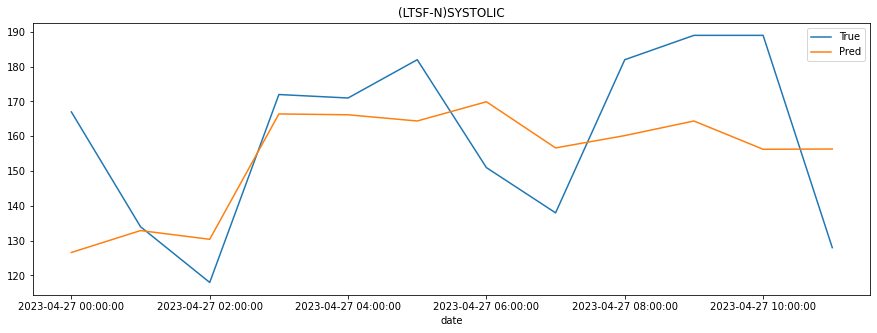

In [130]:
new_df2.plot(title = '(LTSF-N)SYSTOLIC',figsize=(15,5))